RETAIL SALE ANALYSIS USING PYTHON|PANDAS|NUMPY

Project Objective was to analysis the data given, find the insights , check what was selling and was giving maximum amount of revenues.

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#LOADING OF DATASETS
import random
from datetime import datetime, timedelta

random.seed(42)

products = {
    "Laptop": ("Electronics", 55000),
    "Wireless Mouse": ("Accessories", 1200),
    "Keyboard": ("Accessories", 2500),
    "Headphones": ("Electronics", 3500),
    "Smartphone": ("Electronics", 28000),
    "Notebook": ("Stationery", 250),
    "Planner": ("Stationery", 500),
    "Desk Lamp": ("Home Office", 1800),
    "Office Chair": ("Furniture", 8500),
    "Backpack": ("Accessories", 2200)
}

regions = ["North", "South", "East", "West"]
customer_types = ["Student", "Professional", "Business"]
payment_methods = ["UPI", "Credit Card", "Debit Card", "Cash"]

data = []

start_date = datetime(2026, 1, 1)

for i in range(500):

    product = random.choice(list(products.keys()))
    category, price = products[product]

    quantity = random.randint(1, 5)
    discount = random.choice([0, 0.05, 0.10, 0.15])

    revenue = quantity * price * (1 - discount)

    data.append({
        "Order_ID": f"ORD{i+1:04d}",
        "Date": start_date + timedelta(days=random.randint(0, 180)),
        "Product": product,
        "Category": category,
        "Region": random.choice(regions),
        "Customer_Type": random.choice(customer_types),
        "Payment_Method": random.choice(payment_methods),
        "Quantity": quantity,
        "Unit_Price": price,
        "Discount": discount,
        "Revenue": round(revenue, 2)
    })

df = pd.DataFrame(data)

df.head()

,Order_ID,Date,Product,Category,Region,Customer_Type,Payment_Method,Quantity,Unit_Price,Discount,Revenue
0,ORD0001,2026-03-04,Wireless Mouse,Accessories,South,Student,UPI,1,1200,0.10,1080.0
1,ORD0002,2026-01-09,Office Chair,Furniture,North,Student,Credit Card,1,8500,0.15,7225.0
2,ORD0003,2026-05-24,Headphones,Electronics,South,Business,Cash,5,3500,0.00,17500.0
3,ORD0004,2026-01-02,Headphones,Electronics,South,Business,Cash,4,3500,0.10,12600.0
4,ORD0005,2026-02-25,Notebook,Stationery,East,Student,UPI,3,250,0.05,712.5


In [4]:
#finding rows and columns, basic informations
df.shape
df.columns
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        500 non-null    object        
 1   Date            500 non-null    datetime64[ns]
 2   Product         500 non-null    object        
 3   Category        500 non-null    object        
 4   Region          500 non-null    object        
 5   Customer_Type   500 non-null    object        
 6   Payment_Method  500 non-null    object        
 7   Quantity        500 non-null    int64         
 8   Unit_Price      500 non-null    int64         
 9   Discount        500 non-null    float64       
 10  Revenue         500 non-null    float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 43.1+ KB


,0
Order_ID,0
Date,0
Product,0
Category,0
Region,0
Customer_Type,0
Payment_Method,0
Quantity,0
Unit_Price,0
Discount,0


In [10]:
#checking for duplicates
df.duplicated().sum()
df = df.drop_duplicates()
df["Date"] = pd.to_datetime(df["Date"])
df["Date"].dtype
df[["Quantity", "Unit_Price", "Discount", "Revenue"]].describe()
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Negative prices:", (df["Unit_Price"] < 0).sum())
print("Negative revenue:", (df["Revenue"] < 0).sum())
print("Discount above 100%:", (df["Discount"] > 1).sum())

Negative quantities: 0
Negative prices: 0
Negative revenue: 0
Discount above 100%: 0


In [12]:
product_sales = df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)

product_sales


,Quantity
Product,
Backpack,186
Desk Lamp,170
Notebook,169
Keyboard,168
Planner,164
Wireless Mouse,150
Headphones,135
Smartphone,132
Office Chair,128


In [13]:
#FINDING TOTAL REVENUE
print("Total Revenue:", df["Revenue"].sum())
print("Total Units Sold:", df["Quantity"].sum())
print("Average Order Revenue:", df["Revenue"].mean())

Total Revenue: 11878800.0
Total Units Sold: 1515
Average Order Revenue: 23757.6


In [14]:
product_sales.head(5)

,Quantity
Product,
Backpack,186
Desk Lamp,170
Notebook,169
Keyboard,168
Planner,164


In [15]:
product_revenue = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)

product_revenue
product_revenue.head(5)

,Revenue
Product,
Laptop,5651250.0
Smartphone,3446800.0
Office Chair,1011925.0
Headphones,434875.0
Keyboard,391500.0


In [17]:
category_revenue = df.groupby("Category")["Revenue"].sum().sort_values(ascending=False)

category_revenue



,Revenue
Category,
Electronics,9532925.0
Furniture,1011925.0
Accessories,936880.0
Home Office,281520.0
Stationery,115550.0


In [18]:
region_revenue = df.groupby("Region")["Revenue"].sum().sort_values(ascending=False)

region_revenue

,Revenue
Region,
South,3450580.0
West,2876052.5
North,2823725.0
East,2728442.5


In [19]:
customer_revenue = df.groupby("Customer_Type")["Revenue"].sum().sort_values(ascending=False)

customer_revenue

,Revenue
Customer_Type,
Student,5162657.5
Business,3405227.5
Professional,3310915.0


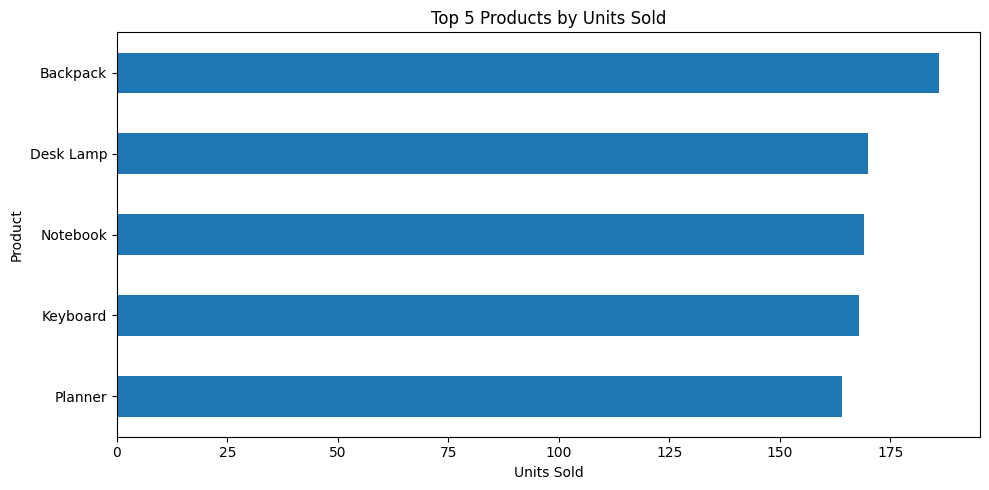

In [20]:
#TOP 5 PRODUCTS CHECKING
plt.figure(figsize=(10, 5))

product_sales.head(5).sort_values().plot(kind="barh")

plt.title("Top 5 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

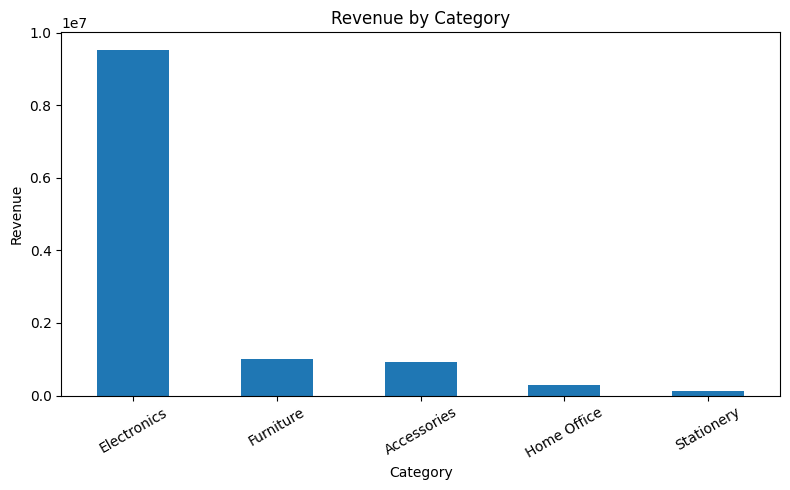

In [21]:
#REVENUE ANALYIS BY CATERGORY AND DISPLAY
plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

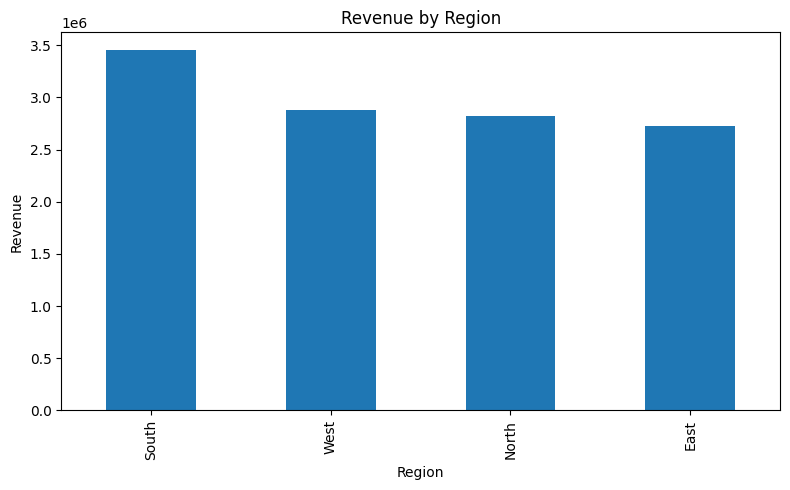

In [22]:
#REVENUE BY REGION AND DISPLAY
plt.figure(figsize=(8, 5))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

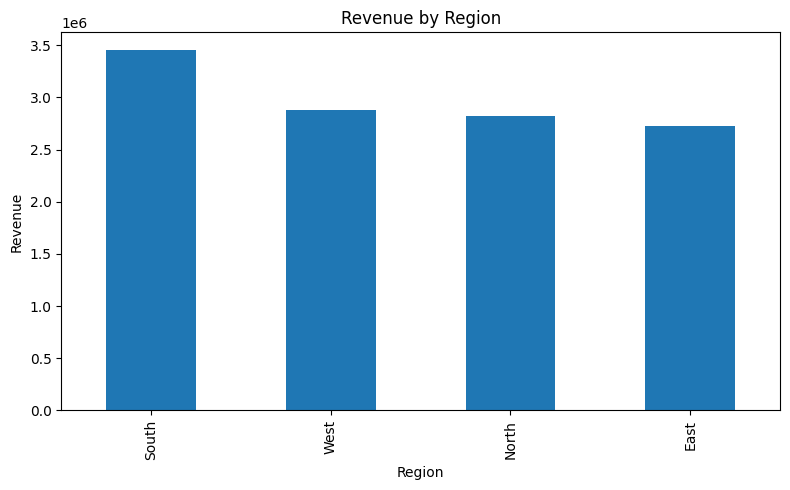

In [23]:
plt.figure(figsize=(8, 5))

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

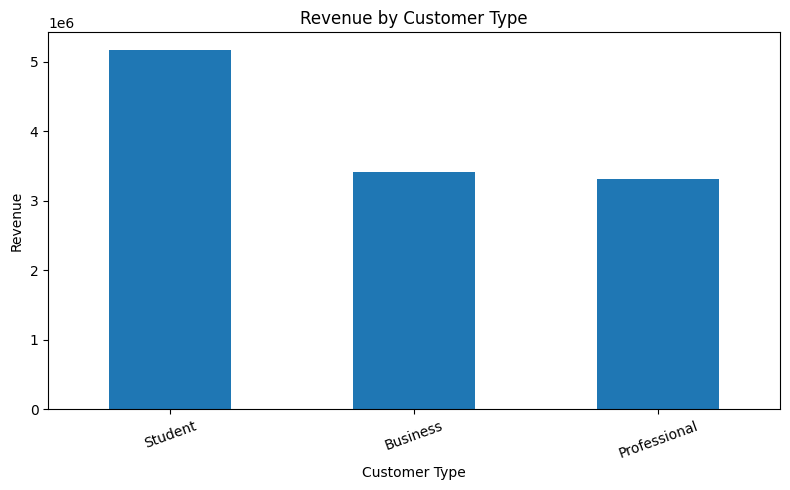

In [24]:
plt.figure(figsize=(8, 5))

customer_revenue.plot(kind="bar")

plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Revenue")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


In [26]:
print("TOP 5 PRODUCTS BY UNITS:")
print(product_sales.head(5))

print("\nTOP 5 PRODUCTS BY REVENUE:")
print(product_revenue.head(5))

print("\nREVENUE BY CATEGORY:")
print(category_revenue)

print("\nREVENUE BY REGION:")
print(region_revenue)

print("\nREVENUE BY CUSTOMER TYPE:")
print(customer_revenue)

monthly_revenue = df.set_index('Date').resample('ME')['Revenue'].sum()
print("\nMONTHLY REVENUE:")
print(monthly_revenue)

TOP 5 PRODUCTS BY UNITS:
Product
Backpack     186
Desk Lamp    170
Notebook     169
Keyboard     168
Planner      164
Name: Quantity, dtype: int64

TOP 5 PRODUCTS BY REVENUE:
Product
Laptop          5651250.0
Smartphone      3446800.0
Office Chair    1011925.0
Headphones       434875.0
Keyboard         391500.0
Name: Revenue, dtype: float64

REVENUE BY CATEGORY:
Category
Electronics    9532925.0
Furniture      1011925.0
Accessories     936880.0
Home Office     281520.0
Stationery      115550.0
Name: Revenue, dtype: float64

REVENUE BY REGION:
Region
South    3450580.0
West     2876052.5
North    2823725.0
East     2728442.5
Name: Revenue, dtype: float64

REVENUE BY CUSTOMER TYPE:
Customer_Type
Student         5162657.5
Business        3405227.5
Professional    3310915.0
Name: Revenue, dtype: float64

MONTHLY REVENUE:
Date
2026-01-31    2976545.0
2026-02-28    1780660.0
2026-03-31    1028937.5
2026-04-30    1257817.5
2026-05-31    1839200.0
2026-06-30    2995640.0
Freq: ME, Name: Revenu

/tmp/ipykernel_1986/4245500623.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_revenue = df.set_index('Date').resample('M')['Revenue'].sum()


In [27]:
top_product_units = product_sales.idxmax()
top_product_units_value = product_sales.max()

top_product_revenue = product_revenue.idxmax()
top_product_revenue_value = product_revenue.max()

top_category = category_revenue.idxmax()
top_category_value = category_revenue.max()

top_region = region_revenue.idxmax()
top_region_value = region_revenue.max()

top_customer = customer_revenue.idxmax()
top_customer_value = customer_revenue.max()

best_month = monthly_revenue.idxmax()
best_month_value = monthly_revenue.max()

print("KEY BUSINESS INSIGHTS")
print("----------------------")

print(f"• {top_product_units} was the best-selling product with {top_product_units_value} units sold.")
print(f"• {top_product_revenue} generated the highest revenue at ₹{top_product_revenue_value:,.2f}.")
print(f"• {top_category} was the highest-revenue category at ₹{top_category_value:,.2f}.")
print(f"• {top_region} generated the highest regional revenue at ₹{top_region_value:,.2f}.")
print(f"• {top_customer} customers contributed the highest revenue at ₹{top_customer_value:,.2f}.")
print(f"• {best_month} was the strongest month with revenue of ₹{best_month_value:,.2f}.")

KEY BUSINESS INSIGHTS
----------------------
• Backpack was the best-selling product with 186 units sold.
• Laptop generated the highest revenue at ₹5,651,250.00.
• Electronics was the highest-revenue category at ₹9,532,925.00.
• South generated the highest regional revenue at ₹3,450,580.00.
• Student customers contributed the highest revenue at ₹5,162,657.50.
• 2026-06-30 00:00:00 was the strongest month with revenue of ₹2,995,640.00.


## Business Insights & Conclusion

The analysis identified key patterns in product performance, regional sales,
customer segments, and monthly revenue.

The highest-performing products and categories can be prioritized for
inventory and marketing decisions. Regional performance can help identify
strong markets, while customer-type analysis can help businesses better
target their key customer segments.

Overall, the analysis demonstrates how Python can be used to clean,
analyze, visualize, and interpret retail sales data to support
data-driven business decisions.